In [1]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.2f}'.format


import matplotlib.pyplot as plt

from datetime import datetime, date
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/Propsih/test/main/data_test.csv',
    sep=';',
    parse_dates=['VALUE_DAY'], 
    dayfirst=True              
)

df.VALUE_DAY = df.VALUE_DAY.dt.date

df.head()

,CLIENT_ID,VALUE_DAY,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT
0,3596869440,2021-09-30,18.00,8.00,9.00
1,181778433,2021-09-30,7.00,3.00,3.00
2,4271531990,2021-09-30,2.00,0.00,0.00
3,3949165697,2021-09-30,15.00,4.00,5.00
4,1926920317,2021-09-30,3.00,0.00,0.00


In [28]:
# убедимся, что действительно когда в одной колонке пустое значение, то так везде, дабы быть спокойны, что не терям ничего

list(df[df['TRAN_ACTIVE_30_CNT'].isna()].index) == list(df[df['OPER_ACTIVE_30_CNT'].isna()].index) == list(df[df['DIGITAL_30_CNT'].isna()].index) # True

# теперь можем спокойно дропать nan

df.drop_duplicates(ignore_index=True).dropna(inplace=True, ignore_index=True)

Описание полей (названий столбцов): 

•	`CLIENT_ID` - идентификатор клиента; 

•	`VALUE_DAY` - отчетная дата (месяц); 

•	`DIGITAL_30_CNT` - кол-во входов в мобильное приложение за последние 30 дней на отчетную дату; 

•	`TRAN_ACTIVE_30_CNT` - кол-во транзакций в мобильном приложении за последние 30 дней на отчетную дату; 

•	`OPER_ACTIVE_30_CNT` - кол-во операций (транзакции+нефинансовые операции) в мобильном приложении за последние 30 дней на отчетную дату

In [132]:
dfc = df.merge(
     df.groupby('CLIENT_ID')['VALUE_DAY'].transform('min')
    ,left_index=True
    ,right_index=True
    ,suffixes=['_CURRENT', '_FIRST']
).astype({'VALUE_DAY_CURRENT': 'datetime64[ns]', 'VALUE_DAY_FIRST': 'datetime64[ns]'})

dfc['digital_act'] = 1 * (dfc['DIGITAL_30_CNT'] > 0)
dfc['trans_act'] = 1 * (dfc['TRAN_ACTIVE_30_CNT'] > 0)
dfc['oper_act'] = 1 * (dfc['OPER_ACTIVE_30_CNT'] > 0)

dfc

,CLIENT_ID,VALUE_DAY_CURRENT,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT,VALUE_DAY_FIRST,digital_act,trans_act,oper_act
0,3596869440,2021-09-30,18.00,8.00,9.00,2021-09-30,1,1,1
1,181778433,2021-09-30,7.00,3.00,3.00,2021-09-30,1,1,1
2,4271531990,2021-09-30,2.00,0.00,0.00,2021-09-30,1,0,0
3,3949165697,2021-09-30,15.00,4.00,5.00,2021-09-30,1,1,1
4,1926920317,2021-09-30,3.00,0.00,0.00,2021-09-30,1,0,0
...,...,...,...,...,...,...,...,...,...
711164,4253033414,2022-02-28,2.00,0.00,0.00,2021-09-30,1,0,0
711165,4243322997,2022-02-28,2.00,0.00,0.00,2021-09-30,1,0,0
711166,67461867,2022-02-28,3.00,0.00,0.00,2021-09-30,1,0,0
711167,1780553365,2022-02-28,4.00,0.00,2.00,2022-01-31,1,0,1


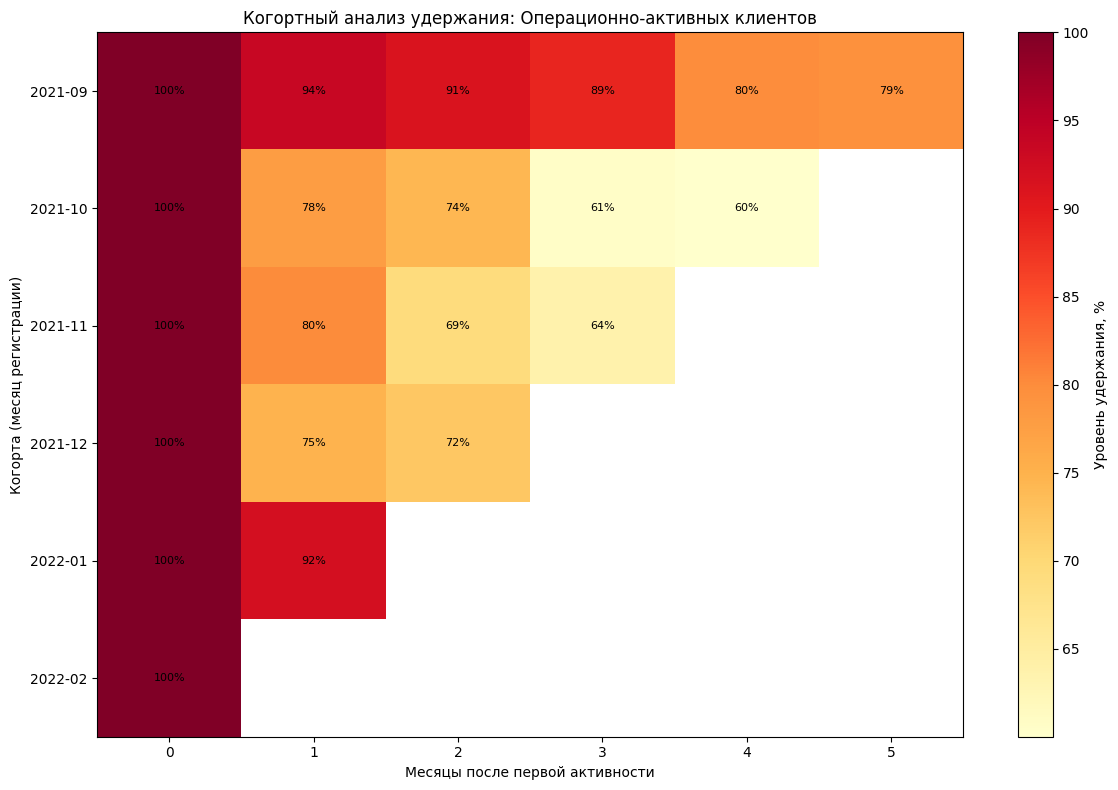

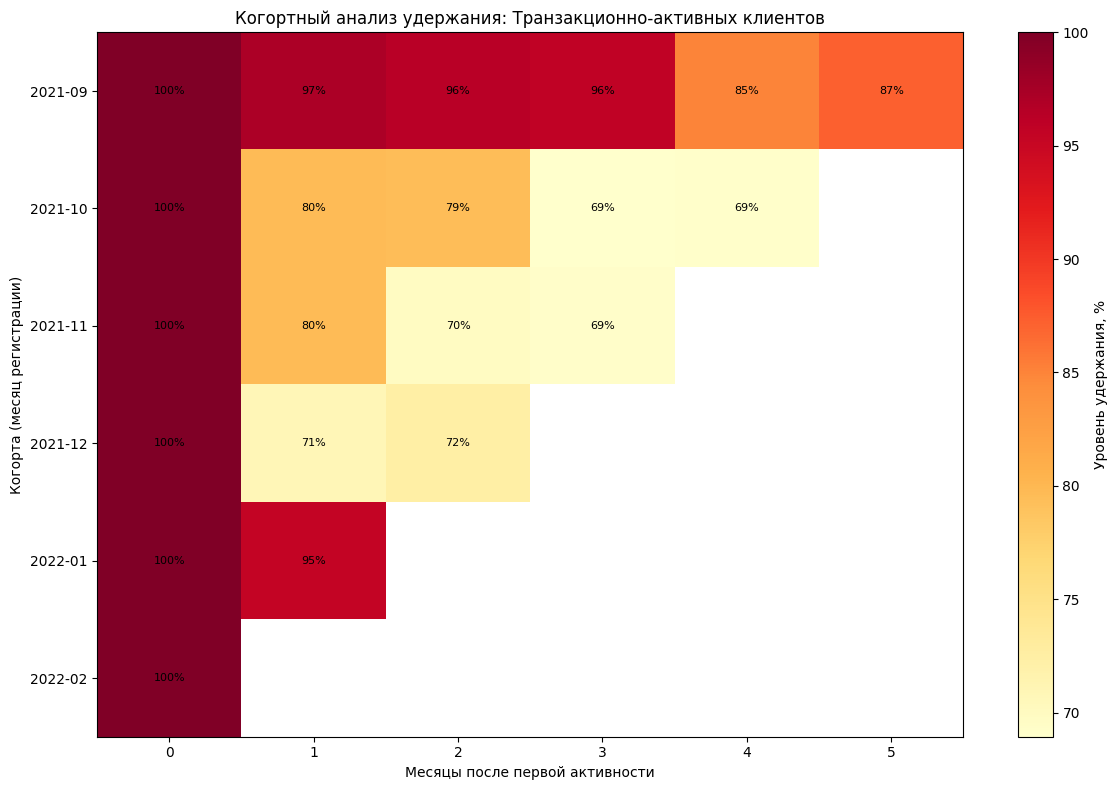

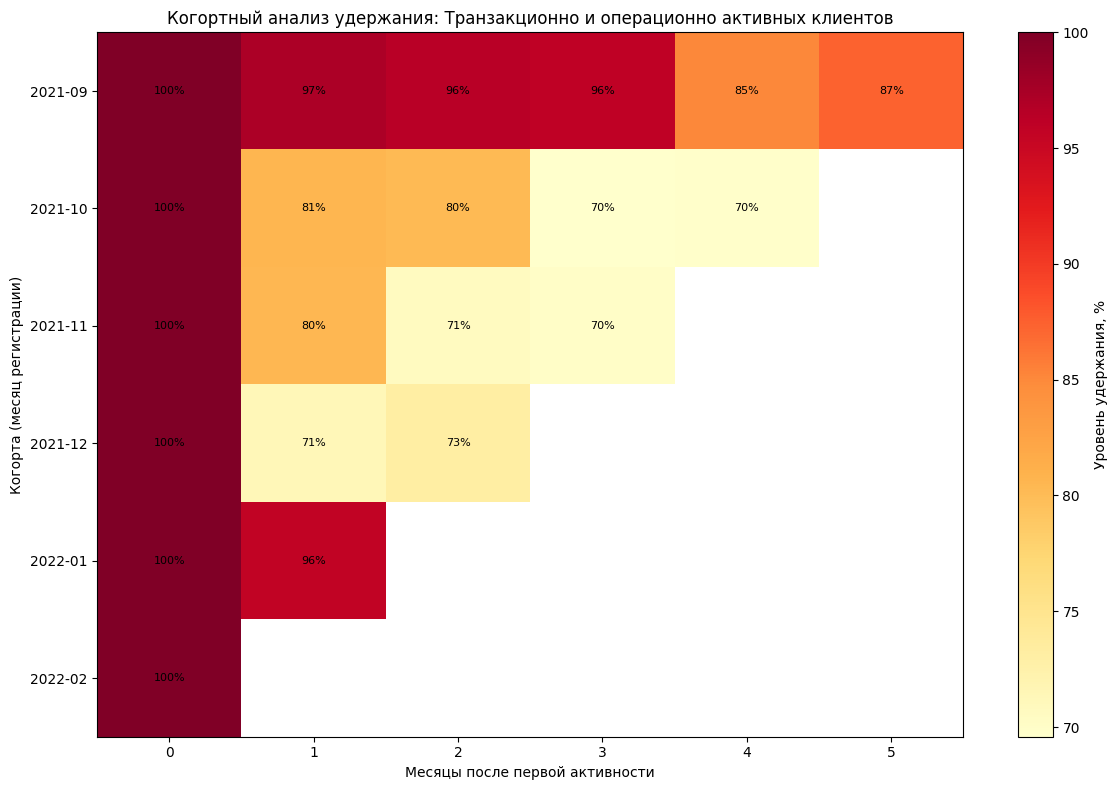

In [144]:
def build_cohort_matrix(df, active_flag, title):
    """
    Функция для построения матрицы удержания на основе когорты.
    
    Параметры:
      df         - DataFrame с данными.
      active_flag - строка, содержащая имя столбца с бинарным индикатором активности (1/0).
      title      - Заголовок графика.
    """
    # Фильтруем данные: оставляем только записи, где активность равна 1
    if isinstance(active_flag, str):
        condition = df[active_flag] == 1
    else:
        condition = active_flag

    # Фильтруем данные
    df_active = df[condition].copy()

    # Определяем когору как месяц первой активности
    df_active['cohort_first'] = df_active['VALUE_DAY_FIRST'].dt.to_period('M')
    # Определяем текущий месяц активности
    df_active['cohort_current'] = df_active['VALUE_DAY_CURRENT'].dt.to_period('M')
    # Вычисляем разницу в месяцах между текущей датой и датой первой активности
    df_active['period_index'] = (df_active['cohort_current'] - df_active['cohort_first']).apply(lambda x: x.n)
    
    # Группируем по когортам и периодам, считаем уникальное количество клиентов
    cohort_data = df_active.groupby(['cohort_first', 'period_index'])['CLIENT_ID'].nunique().reset_index()
    
    # Преобразуем в матрицу: строки – когорты, столбцы – месяцы после первой активности
    cohort_counts = cohort_data.pivot(index='cohort_first', columns='period_index', values='CLIENT_ID')
    # Размер когорты – это число клиентов в периоде 0
    cohort_sizes = cohort_counts.iloc[:, 0]
    # Вычисляем уровни удержания в процентах
    retention = cohort_counts.divide(cohort_sizes, axis=0) * 100
    
    # Визуализируем результат в виде тепловой карты
    plt.figure(figsize=(12, 8))
    plt.imshow(retention, aspect='auto', cmap='YlOrRd')
    plt.title(f'Когортный анализ удержания: {title}')
    plt.xlabel('Месяцы после первой активности')
    plt.ylabel('Когорта (месяц регистрации)')
    
    # Добавляем числовые значения на карту
    for i in range(retention.shape[0]):
        for j in range(retention.shape[1]):
            value = retention.iloc[i, j]
            if not np.isnan(value):
                plt.text(j, i, f'{value:.0f}%', ha='center', va='center', color='black', fontsize=8)
    
    plt.xticks(np.arange(retention.shape[1]), retention.columns)
    plt.yticks(np.arange(retention.shape[0]), retention.index.astype(str))
    plt.colorbar(label='Уровень удержания, %')
    plt.tight_layout()
    plt.show()

# Пример вызова функции для разных типов активности:
# Анализ для операционно-активных клиентов (столбец 'oper_act')
build_cohort_matrix(dfc, 'digital_act', 'Операционно-активных клиентов')

# Анализ для транзакционно-активных клиентов (столбец 'trans_act')
build_cohort_matrix(dfc, 'trans_act', 'Транзакционно-активных клиентов')

build_cohort_matrix(dfc, (dfc['trans_act'] == 1) & (dfc['digital_act'] == 1), 'Транзакционно и операционно активных клиентов')


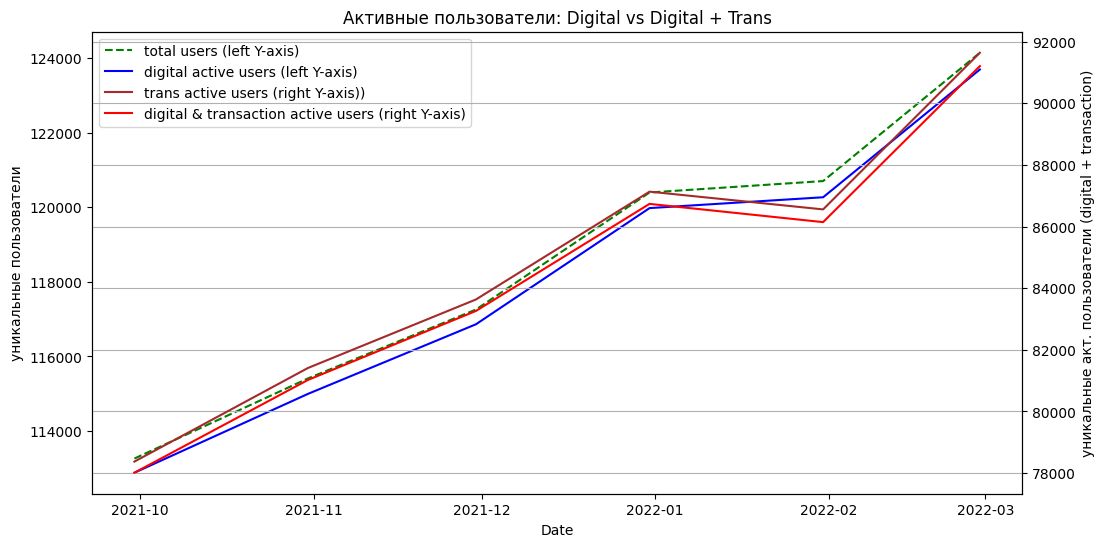

In [117]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(dfc.groupby('VALUE_DAY_CURRENT').agg({'CLIENT_ID': pd.Series.nunique}), 
         'g--', label='total users (left Y-axis)')

df_digital = dfc[dfc.DIGITAL_30_CNT > 0].groupby('VALUE_DAY_CURRENT').agg({'CLIENT_ID': pd.Series.nunique})
ax1.plot(df_digital, 'b-', label='digital active users (left Y-axis)')
ax1.set_xlabel('Date')
ax1.set_ylabel('уникальные пользователи')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
df_trans = dfc[dfc.TRAN_ACTIVE_30_CNT > 0].groupby('VALUE_DAY_CURRENT').agg({'CLIENT_ID': pd.Series.nunique})
ax2.plot(df_trans, 'brown', label='trans active users (right Y-axis))')
ax2.set_xlabel('Date')
ax2.tick_params(axis='y')

df_digital_tran = dfc[(dfc.DIGITAL_30_CNT > 0) & (dfc.TRAN_ACTIVE_30_CNT > 0)].groupby('VALUE_DAY_CURRENT').agg({'CLIENT_ID': pd.Series.nunique})
ax2.plot(df_digital_tran, 'r-', label='digital & transaction active users (right Y-axis)')
ax2.set_ylabel('уникальные акт. пользователи (digital + transaction)')
ax2.tick_params(axis='y')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('Активные пользователи: Digital vs Digital + Trans')
plt.grid(True)
plt.show()

пришлось прибегнуть в уловке, что можно не заметить с первого взгляда. графики транзакционно активных были по оси Y отображены вместе с клиентами, что активных в приложении и траназакционно, в то время как диждитал активные и общее кол-во уникальных клиентов на другой оси. это было сделано для более визуально ощутимого тренда и некоторой сезонности, что наступает после новогодних праздников и возращения уровня транзакционной активности ближе к марту. как можно заметить, кол-во активных клиентов приложения практически схоже к общему количеству клиентов, а активных транзакционно существенно меньше, что может говорить в первом приближении о том, что банк может являться не основным банком клиента и он просто держит на счету какие-то сбережения, либо пользуется временным выгодным предложением для новых пользователей

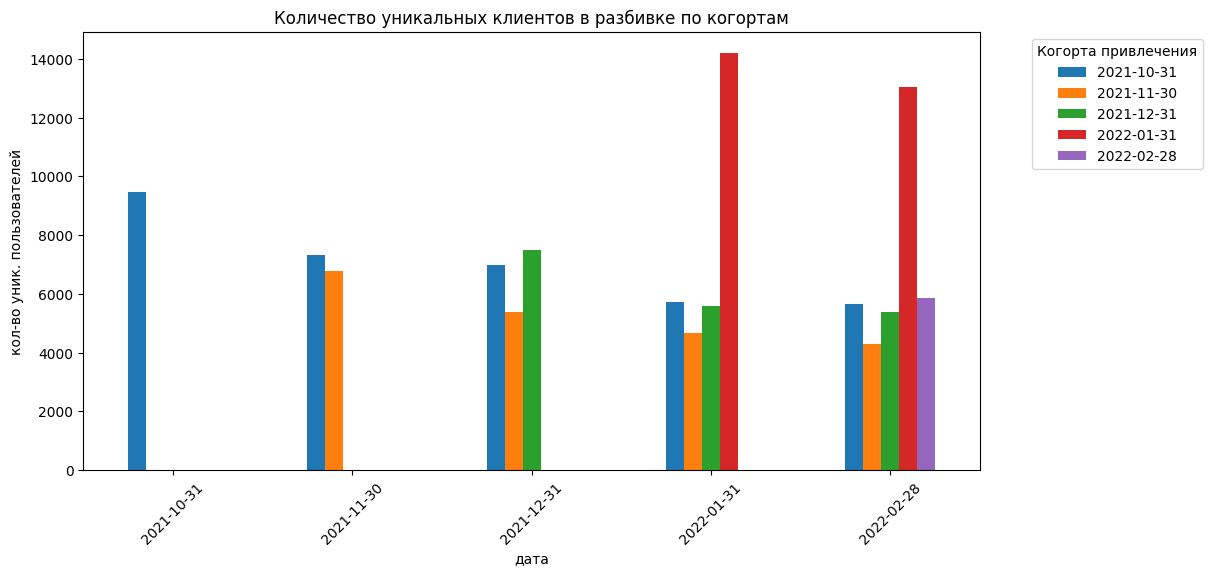

In [114]:
cohort_data = dfc[dfc.VALUE_DAY_FIRST != date(2021, 9, 30)].groupby(['VALUE_DAY_CURRENT', 'VALUE_DAY_FIRST'])['CLIENT_ID'].nunique().unstack().fillna(0)
cohort_data.plot(kind='bar', figsize=(10, 6))

plt.title('Количество уникальных клиентов в разбивке по когортам')
plt.xlabel('дата')
plt.ylabel('кол-во уник. пользователей')
plt.tight_layout()
plt.xticks(rotation=45)
plt.legend(title='Когорта привлечения', bbox_to_anchor=(1.05, 1), loc='upper left');


In [27]:
dfc.describe()

,CLIENT_ID,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT
count,711169.00,711169.00,711169.00,711169.00
mean,2144992290.42,11.59,3.27,4.51
std,1240903276.38,15.67,5.59,7.47
min,8294.00,0.00,0.00,0.00
25%,1066933815.00,3.00,0.00,1.00
50%,2144509216.00,7.00,2.00,2.00
75%,3220847438.00,15.00,4.00,5.00
max,4294935340.00,1247.00,555.00,563.00


стоит отметить, что так как мы не имеем информации до сентбря 2021 года, то все клиенты, что были зарегистрированы до этого тоже попадают в данную когорту. ее следует анализировать иначе, нежели чем остальные когорты

In [7]:
# активные клиенты приложения
# активный клиент - хотя бы раз зашел в приложение за отчетный период

dfc[dfc.DIGITAL_30_CNT > 0].pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='CLIENT_ID', 
    aggfunc=pd.Series.nunique
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,0.996645,0.932715,0.908445,0.885225,0.797139,0.791595
2021-10-31,0.000000,0.987125,0.767518,0.732799,0.598565,0.592444
2021-11-30,0.000000,0.000000,0.986881,0.790537,0.683078,0.628833
2021-12-31,0.000000,0.000000,0.000000,0.986542,0.738175,0.713391
2022-01-31,0.000000,0.000000,0.000000,0.000000,0.995141,0.915569
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.987892


In [8]:
# транзакционно активные клиенты
# транзакционно активный клиент - хотя бы раз зашел совершил транзакцию за отчетный период

dfc[dfc.TRAN_ACTIVE_30_CNT > 0].pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='CLIENT_ID', 
    aggfunc=pd.Series.nunique
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,0.691935,0.672352,0.665978,0.662376,0.588302,0.603346
2021-10-31,0.000000,0.554770,0.442170,0.440587,0.382440,0.383390
2021-11-30,0.000000,0.000000,0.591392,0.471108,0.413325,0.409198
2021-12-31,0.000000,0.000000,0.000000,0.631312,0.447302,0.457295
2022-01-31,0.000000,0.000000,0.000000,0.000000,0.713893,0.681008
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.646658


In [29]:
# stickness для всех представленных клиентов

dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='DIGITAL_30_CNT', 
    aggfunc='sum'
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,11.054606,10.766009,10.772136,11.805995,9.013120,10.093109
2021-10-31,0.000000,7.122837,6.856374,6.956522,5.384550,5.740080
2021-11-30,0.000000,0.000000,7.395195,8.292600,6.192512,6.677329
2021-12-31,0.000000,0.000000,0.000000,8.598401,7.243704,7.723651
2022-01-31,0.000000,0.000000,0.000000,0.000000,10.755440,12.236673
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,7.911835


In [30]:
# медианное кол-во входов в приложение по когортам

dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='DIGITAL_30_CNT', 
    aggfunc='median'
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,6.000000,7.000000,7.000000,8.000000,7.000000,8.000000
2021-10-31,0.000000,4.000000,5.000000,5.000000,5.000000,5.000000
2021-11-30,0.000000,0.000000,4.000000,5.000000,5.000000,6.000000
2021-12-31,0.000000,0.000000,0.000000,5.000000,5.000000,5.000000
2022-01-31,0.000000,0.000000,0.000000,0.000000,6.000000,8.000000
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000


In [31]:
# среднее кол-во транзакций

dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='TRAN_ACTIVE_30_CNT', 
    aggfunc='sum'
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,2.971324,3.042317,3.085843,3.323304,2.651243,3.001227
2021-10-31,0.000000,1.596032,1.739130,1.901224,1.542528,1.709688
2021-11-30,0.000000,0.000000,1.714328,2.128685,1.692217,1.865419
2021-12-31,0.000000,0.000000,0.000000,1.941772,1.881812,2.149101
2022-01-31,0.000000,0.000000,0.000000,0.000000,3.019224,3.565031
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,1.974420


In [9]:
dfc.groupby('VALUE_DAY_FIRST')\
    .agg({
         'DIGITAL_30_CNT':      'sum'
        ,'TRAN_ACTIVE_30_CNT':  'sum'
        ,'OPER_ACTIVE_30_CNT':  'sum'
    })

,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT
VALUE_DAY_FIRST,,,
2021-09-30,7192891.00,2047294.00,2815794.00
2021-10-31,303804.00,80438.00,107508.00
2021-11-30,193735.00,50206.00,70289.00
2021-12-31,176861.00,44825.00,64362.00
2022-01-31,326511.00,93503.00,131095.00
2022-02-28,46395.00,11578.00,17393.00


In [10]:
dfc.groupby('VALUE_DAY_FIRST')\
    .agg({
         'DIGITAL_30_CNT':      ['mean', 'median']
        ,'TRAN_ACTIVE_30_CNT':  ['mean', 'median']
        ,'OPER_ACTIVE_30_CNT':  ['mean', 'median']
    })

DIGITAL_30_CNT        TRAN_ACTIVE_30_CNT         \
                          mean median               mean median   
VALUE_DAY_FIRST                                                   
2021-09-30               11.92   7.00               3.39   2.00   
2021-10-31                8.64   4.00               2.29   1.00   
2021-11-30                9.16   5.00               2.37   1.00   
2021-12-31                9.57   5.00               2.42   1.00   
2022-01-31               11.99   7.00               3.43   2.00   
2022-02-28                7.91   5.00               1.97   1.00   

                OPER_ACTIVE_30_CNT         
                              mean median  
VALUE_DAY_FIRST                            
2021-09-30                    4.67   2.00  
2021-10-31                    3.06   2.00  
2021-11-30                    3.32   2.00  
2021-12-31                    3.48   2.00  
2022-01-31                    4.81   2.00  
2022-02-28                    2.97   2.00

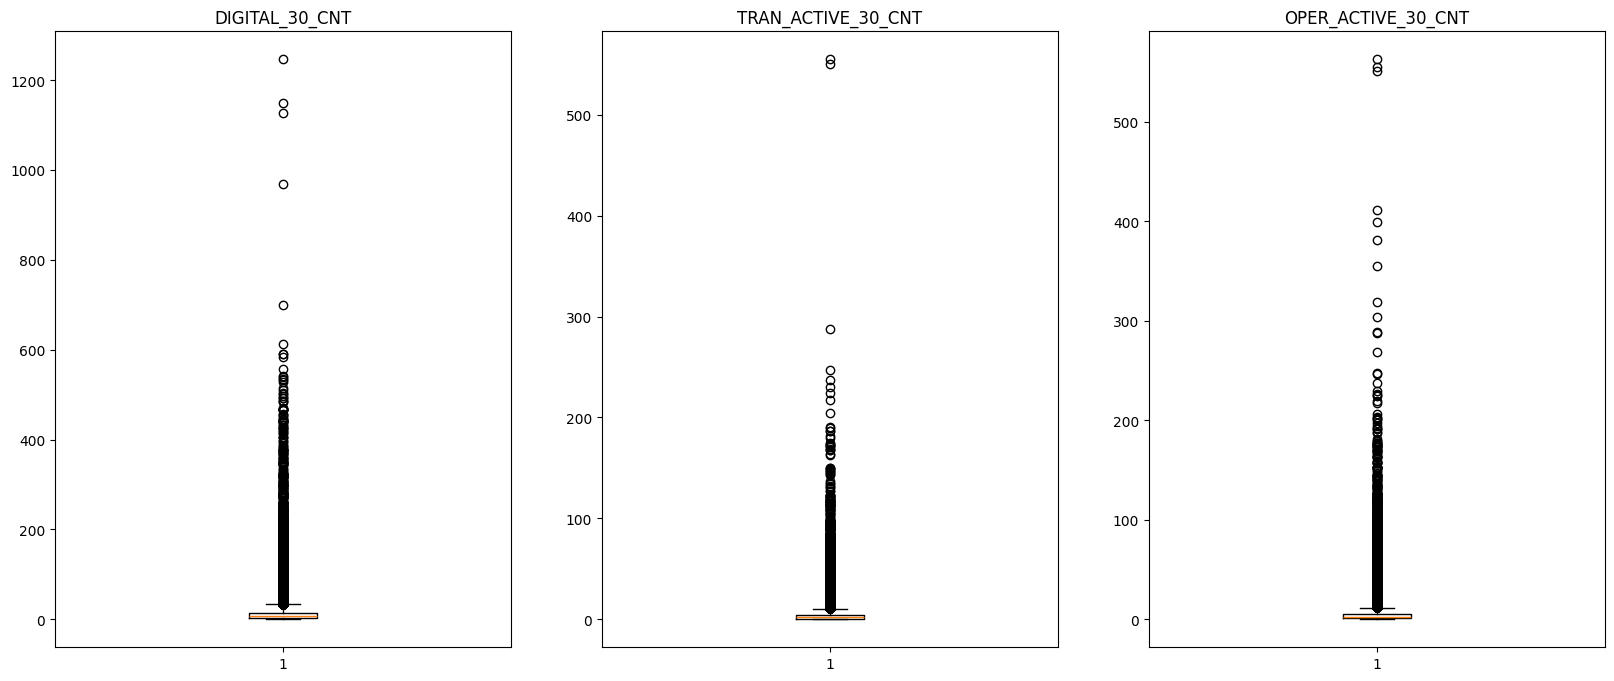

In [53]:
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.boxplot(dfc['DIGITAL_30_CNT'])
plt.title('DIGITAL_30_CNT')

plt.subplot(1, 3, 2)
plt.boxplot(dfc['TRAN_ACTIVE_30_CNT'])
plt.title('TRAN_ACTIVE_30_CNT')

plt.subplot(1, 3, 3)
plt.boxplot(dfc['OPER_ACTIVE_30_CNT'])
plt.title('OPER_ACTIVE_30_CNT');

In [51]:
dfc.groupby(["VALUE_DAY_FIRST", "VALUE_DAY_CURRENT"])["CLIENT_ID"]\
    .nunique()\
    .unstack(fill_value=0)\
    .fillna(0).\
    style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,113265,105936,103154,100491,90529,89891
2021-10-31,0,9476,7319,6997,5716,5656
2021-11-30,0,0,6784,5401,4666,4293
2021-12-31,0,0,0,7505,5588,5394
2022-01-31,0,0,0,0,14201,13041
2022-02-28,0,0,0,0,0,5864


In [118]:
dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='TRAN_ACTIVE_30_CNT', 
    aggfunc='sum'
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,2.971324,3.042317,3.085843,3.323304,2.651243,3.001227
2021-10-31,0.000000,1.596032,1.739130,1.901224,1.542528,1.709688
2021-11-30,0.000000,0.000000,1.714328,2.128685,1.692217,1.865419
2021-12-31,0.000000,0.000000,0.000000,1.941772,1.881812,2.149101
2022-01-31,0.000000,0.000000,0.000000,0.000000,3.019224,3.565031
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,1.974420
